In [ ]:
import scanpy as sc
import scvi
from scvi.model import SCVI

In [35]:
adata = sc.read_h5ad(f"./data/large_merfish/animal4_int.h5ad")


In [36]:
adata

AnnData object with n_obs × n_vars = 215278 × 155
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'

In [24]:
scvi.model.SCVI.setup_anndata(
    adata,
    batch_key="donor_id",
    categorical_covariate_keys=["assay"],
)

In [25]:
N_LATENT = 15
N_LAYERS = 2
N_HIDDEN = 64
MAX_EPOCHS = 10

In [26]:
model = scvi.model.SCVI(adata, n_latent=N_LATENT, n_layers=N_LAYERS, n_hidden=N_HIDDEN)

In [27]:
model.train(max_epochs=MAX_EPOCHS, validation_size=0.1, early_stopping=True)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/ipopx/miniconda3/envs/scvi_env/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return [pytree], LeafSpec()


Epoch 10/10: 100%|██████████| 10/10 [04:50<00:00, 29.18s/it, v_num=1, train_loss_step=255, train_loss_epoch=248]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [04:50<00:00, 29.00s/it, v_num=1, train_loss_step=255, train_loss_epoch=248]


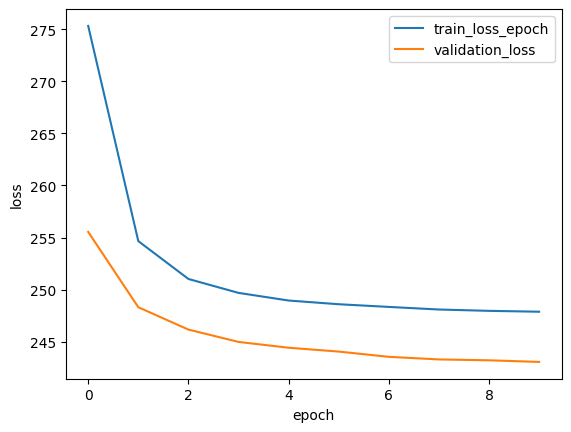

In [31]:
import matplotlib.pyplot as plt

h = model.history

plt.plot(h["train_loss_epoch"], label="train_loss_epoch")
plt.plot(h["validation_loss"], label="validation_loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

/home/ipopx/miniconda3/envs/scvi_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ipopx/miniconda3/envs/scvi_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ipopx/miniconda3/envs/scvi_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


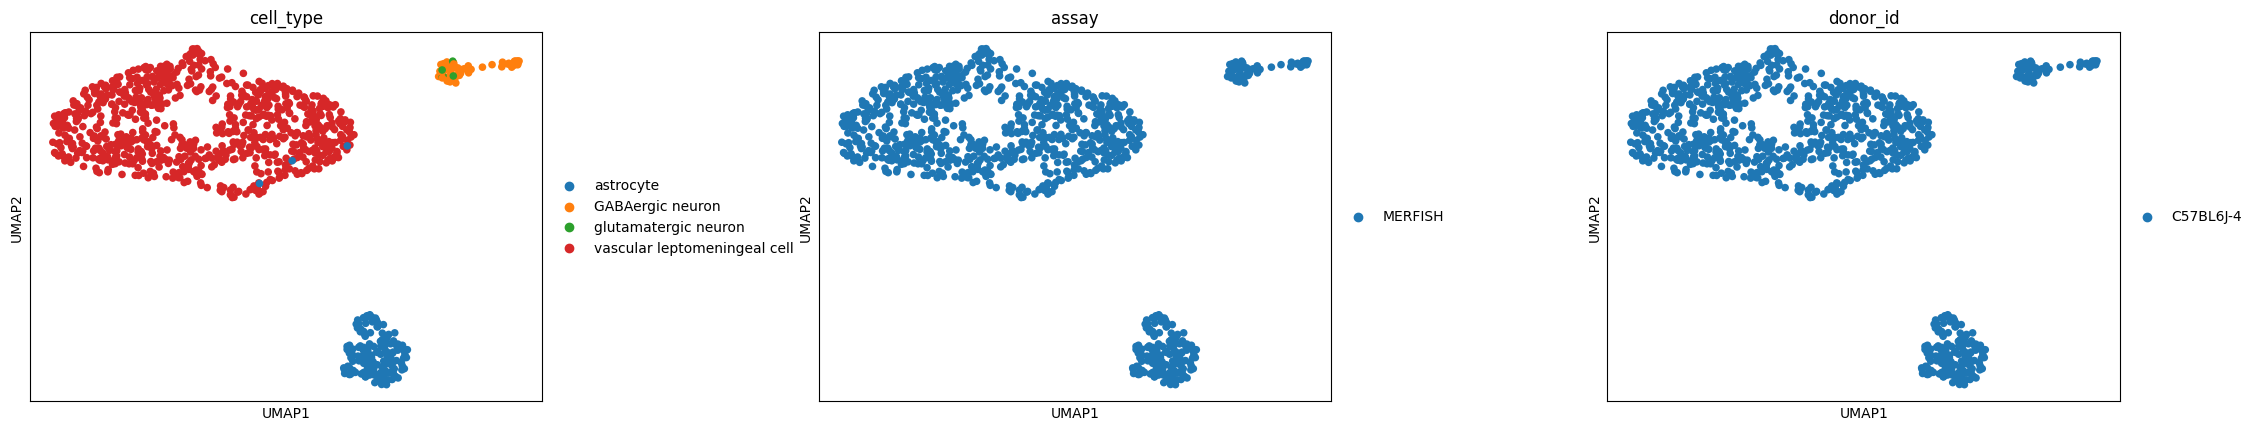

In [34]:
import scanpy as sc

Z = model.get_latent_representation()   # shape (adata.n_obs, n_latent)
adata.obsm["X_scvi"] = Z

adata_1k = adata[:1000].copy()
sc.pp.neighbors(adata_1k, use_rep="X_scvi")
sc.tl.umap(adata_1k)

sc.pl.umap(adata_1k, color=["cell_type", "assay", "donor_id"], wspace=0.4)